# EPL Foul Win Probability Model

## Phase 2 – Target Variable Creation

### Objective

The objective of this notebook is to construct the supervised learning target required for the machine learning model.

Each observation corresponds to a player either:

- Receiving the ball (Ball Receipt*)
- Recovering the ball (Ball Recovery)

The target variable is defined as:

- **1** → The same player wins a foul later in the same possession.
- **0** → Otherwise.

This notebook performs:

1. Load raw datasets
2. Create target variable
3. Explore class distribution
4. Validate generated dataset
5. Save processed dataset

In [1]:
from pathlib import Path
import sys

project_root = Path.cwd().parent

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.data_loader import DataLoader
from src.target_creation import TargetCreator

## Load EPL Event Data

Load the raw StatsBomb event and match datasets.

In [3]:
loader = DataLoader()

events, matches = loader.load_all()

print(f"Events Shape : {events.shape}")
print(f"Matches Shape: {matches.shape}")

2026-06-30 11:26:17,630 | INFO | Loading all datasets...
2026-06-30 11:26:17,633 | INFO | Loading events dataset...
2026-06-30 11:26:28,436 | INFO | Events dataset loaded successfully (1,313,783 rows × 49 columns)
2026-06-30 11:26:28,438 | INFO | Loading matches dataset...
2026-06-30 11:26:28,444 | INFO | Matches dataset loaded successfully (380 rows × 28 columns)
2026-06-30 11:26:28,444 | INFO | All datasets loaded successfully.


Events Shape : (1313783, 49)
Matches Shape: (380, 28)


In [4]:
events.head()

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,pass.end_location,dribble.outcome.id,dribble.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,carry.end_location,duel.outcome.id,duel.outcome.name,competition_id,match_id
0,1,9153e9f4-f69c-4e04-8f64-505592e212cd,1,1,00:00:00.000,0,0,1,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
1,2,3fbcf4e7-94d1-485a-be85-fd26a6af0318,2,1,00:00:00.000,0,0,1,0.000000,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
2,3,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,3,1,00:00:00.000,0,0,1,0.000000,100362ee-9311-4187-bd8a-0201d9db2565,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
3,4,100362ee-9311-4187-bd8a-0201d9db2565,4,1,00:00:00.000,0,0,1,0.000000,06a9a4dc-d9c9-40f6-bd89-437ba7fe682d,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058
4,5,2ca23eea-a984-47e4-8243-8f00880ad1c9,5,1,00:00:01.753,0,1,2,0.308263,1f98c89e-2326-4200-8c12-a987fdbbaf2e,...,"60.4, 43.6",NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3754058


## Create Target Variable

Filter candidate events (Ball Receipt* and Ball Recovery) and create the binary target indicating whether the same player wins a foul later in the same possession.

In [5]:
creator = TargetCreator()

dataset = creator.create_target(events)

2026-06-30 11:26:28 | INFO | Creating target variable...
2026-06-30 11:26:29 | INFO | Candidate events found: 381267
2026-06-30 11:47:58 | INFO | Positive targets : 8686
2026-06-30 11:47:58 | INFO | Negative targets : 372581


In [6]:
dataset.head()

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,dribble.outcome.id,dribble.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,carry.end_location,duel.outcome.id,duel.outcome.name,competition_id,match_id,target
5,88200,e7f3536d-3209-4ed2-a3a4-cd1519e44f7f,6,1,00:00:00.898,0,0,2,NaN,b1c7e9af-19b2-47d8-855f-14aa3209648c,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
8,88203,ec0b4585-41ad-4ada-817c-629d0866eeeb,9,1,00:00:01.808,0,1,2,NaN,"575d8b5a-1b10-4f34-98df-579cc0a52a2e, 70fc4868...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
11,88206,5244092d-6381-41a2-9ea8-727bc84aa5e6,12,1,00:00:04.502,0,4,2,NaN,3d440f32-9181-4e21-8d9d-f6993914f36c,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
14,88209,38650027-fd3b-42be-8fc3-d1a23c617665,15,1,00:00:06.655,0,6,2,NaN,234fa315-2c07-44f5-a31b-d993a98ce386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
17,88212,133fb108-6aff-45d7-8311-770dfc2d4810,18,1,00:00:10.480,0,10,2,NaN,f50a6695-4769-4c8b-a0cf-473df4d91dcf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0


## Dataset Summary

In [7]:
print(dataset.shape)

dataset.info()

(381267, 50)
<class 'pandas.DataFrame'>
Index: 381267 entries, 5 to 1313777
Data columns (total 50 columns):
 #   Column                     Non-Null Count   Dtype  
---  ------                     --------------   -----  
 0   Unnamed: 0                 381267 non-null  int64  
 1   id                         381267 non-null  str    
 2   index                      381267 non-null  int64  
 3   period                     381267 non-null  int64  
 4   timestamp                  381267 non-null  str    
 5   minute                     381267 non-null  int64  
 6   second                     381267 non-null  int64  
 7   possession                 381267 non-null  int64  
 8   duration                   40943 non-null   float64
 9   related_events             360011 non-null  str    
 10  location                   381267 non-null  str    
 11  under_pressure             34829 non-null   object 
 12  counterpress               0 non-null       object 
 13  type.id                    3812

In [8]:
dataset.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,381267.0,NaN,NaN,NaN,655458.763407,379100.905621,6.0,327257.5,654458.0,983581.0,1313781.0
id,381267,381267,e7f3536d-3209-4ed2-a3a4-cd1519e44f7f,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
index,381267.0,NaN,NaN,NaN,1728.393409,1017.164636,6.0,851.0,1710.0,2579.0,4262.0
period,381267.0,NaN,NaN,NaN,1.488416,0.499866,1.0,1.0,1.0,2.0,2.0
timestamp,381267,349153,00:00:00.914,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
minute,381267.0,NaN,NaN,NaN,44.62835,27.029716,0.0,21.0,45.0,67.0,100.0
second,381267.0,NaN,NaN,NaN,29.282262,17.350862,0.0,14.0,29.0,44.0,59.0
possession,381267.0,NaN,NaN,NaN,92.618498,54.948467,2.0,45.0,91.0,138.0,238.0
duration,40943.0,NaN,NaN,NaN,0.000559,0.025921,0.0,0.0,0.0,0.0,2.623528
related_events,360011,351732,890e4b4f-e8c2-4138-ba22-0afefcb2d786,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Target Distribution

Check whether the dataset is balanced before model development.

In [9]:
dataset["target"].value_counts()

target
0    372581
1      8686
Name: count, dtype: int64

In [10]:
dataset["target"].value_counts(normalize=True)

target
0    0.977218
1    0.022782
Name: proportion, dtype: float64

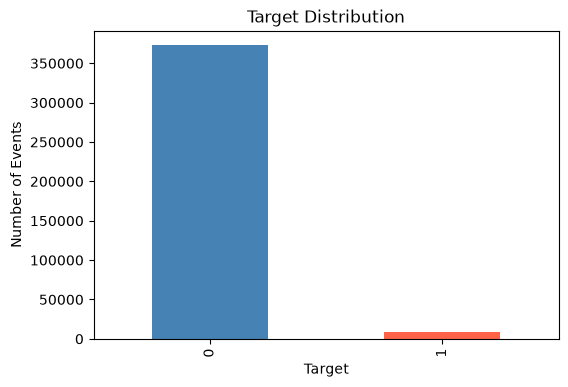

In [11]:
plt.figure(figsize=(6,4))

dataset["target"].value_counts().plot(
    kind="bar",
    color=["steelblue", "tomato"]
)

plt.title("Target Distribution")

plt.xlabel("Target")

plt.ylabel("Number of Events")

plt.show()

## Candidate Event Types

Verify that the dataset contains only Ball Receipt* and Ball Recovery events.

In [12]:
dataset["type.name"].value_counts()

type.name
Ball Receipt*    340324
Ball Recovery     40943
Name: count, dtype: int64

In [13]:
## Missing Value Analysis

In [14]:
missing = (
    dataset
    .isnull()
    .sum()
    .sort_values(ascending=False)
)

missing.head(20)

counterpress           381267
duel.outcome.id        381267
pass.type.name         381267
pass.outcome.id        381267
pass.outcome.name      381267
pass.receipient.id     381267
pass.recipient.name    381267
pass.end_location      381267
dribble.outcome.id     381267
pass.type.id           381267
pass.length            381267
pass.angle             381267
pass.height.id         381267
pass.height.name       381267
pass.body_part.name    381267
pass.body_part.id      381267
tactics.lineup         381267
tactics.formation      381267
duel.outcome.name      381267
carry.end_location     381267
dtype: int64

## Save Processed Dataset

Persist the target dataset for the next phase (Feature Engineering).

In [15]:
creator.save_dataset(dataset)

2026-06-30 11:48:07 | INFO | Dataset saved to C:\Users\91900\Teamwork_Online\epl-foul-prediction\data\processed\model_dataset.csv


WindowsPath('C:/Users/91900/Teamwork_Online/epl-foul-prediction/data/processed/model_dataset.csv')

In [16]:
saved_dataset = pd.read_csv(
    "../data/processed/model_dataset.csv"
)

saved_dataset.head()

,Unnamed: 0,id,index,period,timestamp,minute,second,possession,duration,related_events,...,dribble.outcome.id,dribble.outcome.name,ball_receipt.outcome.id,ball_receipt.outcome.name,carry.end_location,duel.outcome.id,duel.outcome.name,competition_id,match_id,target
0,88200,e7f3536d-3209-4ed2-a3a4-cd1519e44f7f,6,1,00:00:00.898,0,0,2,NaN,b1c7e9af-19b2-47d8-855f-14aa3209648c,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
1,88203,ec0b4585-41ad-4ada-817c-629d0866eeeb,9,1,00:00:01.808,0,1,2,NaN,"575d8b5a-1b10-4f34-98df-579cc0a52a2e, 70fc4868...",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
2,88206,5244092d-6381-41a2-9ea8-727bc84aa5e6,12,1,00:00:04.502,0,4,2,NaN,3d440f32-9181-4e21-8d9d-f6993914f36c,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
3,88209,38650027-fd3b-42be-8fc3-d1a23c617665,15,1,00:00:06.655,0,6,2,NaN,234fa315-2c07-44f5-a31b-d993a98ce386,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0
4,88212,133fb108-6aff-45d7-8311-770dfc2d4810,18,1,00:00:10.480,0,10,2,NaN,f50a6695-4769-4c8b-a0cf-473df4d91dcf,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,3753972,0


In [17]:
saved_dataset.shape

(381267, 50)

# Conclusion

## Summary

In this phase, the supervised learning target for the **EPL Foul Win Probability Model** was successfully constructed from the raw StatsBomb event data.

The following tasks were completed:

- Loaded the EPL event and match datasets.
- Identified the candidate events:
  - **Ball Receipt***
  - **Ball Recovery**
- Created the binary target variable indicating whether the **same player** subsequently won a **Foul Won** event within the **same possession**.
- Validated the generated dataset and confirmed that it contains only the required candidate events.
- Examined the target distribution and missing values.
- Saved the processed dataset for the next stage of the machine learning pipeline.

## Dataset Summary

| Metric | Value |
|--------|------:|
| Original Event Records | **1,313,783** |
| Candidate Events | **381,267** |
| Positive Class (Target = 1) | **8,686** |
| Negative Class (Target = 0) | **372,581** |
| Number of Features | **50** |

## Key Observations

- The target creation process successfully reduced the original event dataset to only the events relevant to this prediction task.
- The generated dataset is **highly imbalanced**, with approximately **2.28% positive examples** and **97.72% negative examples**.
- This level of imbalance is expected because only a small proportion of ball receipts or recoveries result in the player subsequently winning a foul.
- Several event-specific attributes contain missing values. These are expected because many StatsBomb fields are only populated for particular event types (for example, pass-related or duel-related events).

## Next Steps

The processed dataset generated in this phase will serve as the input for the **Feature Engineering** stage. The next phase will focus on:

- Extracting spatial features from event locations.
- Engineering possession-level and temporal features.
- Creating contextual match features.
- Handling missing values and categorical variables.
- Producing a model-ready dataset for machine learning algorithms.